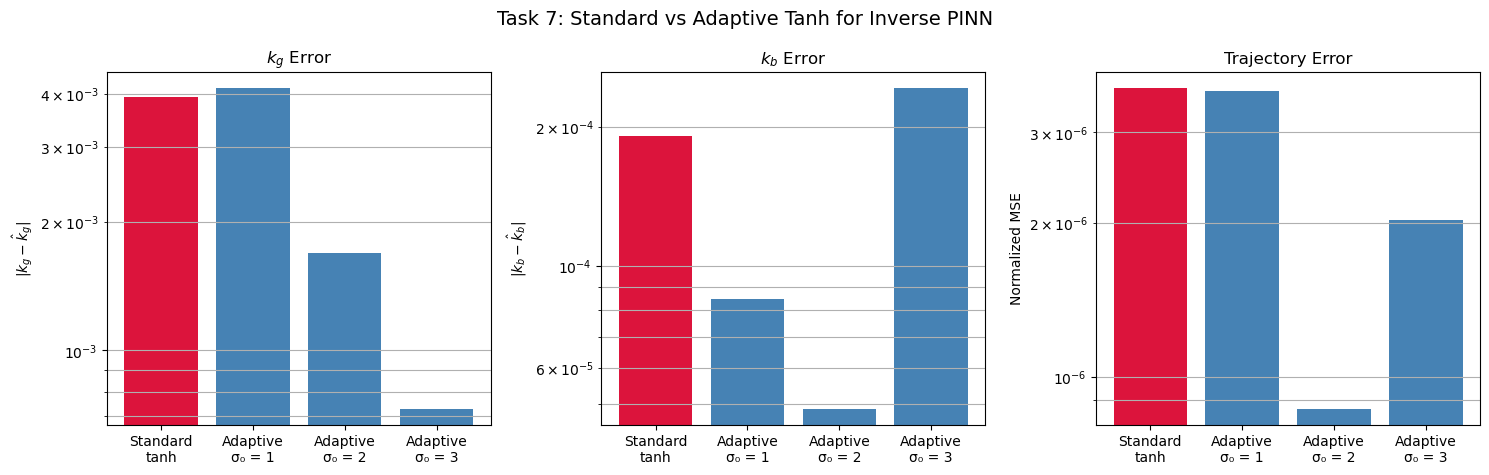

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Labels
labels = [
    "Standard\ntanh",
    "Adaptive\nσ₀ = 1",
    "Adaptive\nσ₀ = 2",
    "Adaptive\nσ₀ = 3"
]

x = np.arange(len(labels))

# Results
kg_error = np.array([3.937e-03, 4.119e-03, 1.692e-03, 7.282e-04])
kb_error = np.array([1.910e-04, 8.480e-05, 4.881e-05, 2.427e-04])
mse_norm = np.array([3.659e-06, 3.617e-06, 8.658e-07, 2.025e-06])

# Different color for standard tanh
bar_colors = ["crimson", "steelblue", "steelblue", "steelblue"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

# --- kg error ---
axes[0].bar(x, kg_error, color=bar_colors)
axes[0].set_yscale("log")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel(r"$|k_g - \hat{k}_g|$")
axes[0].set_title(r"$k_g$ Error")
axes[0].grid(True, which="both", axis="y")

# --- kb error ---
axes[1].bar(x, kb_error, color=bar_colors)
axes[1].set_yscale("log")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel(r"$|k_b - \hat{k}_b|$")
axes[1].set_title(r"$k_b$ Error")
axes[1].grid(True, which="both", axis="y")

# --- normalized MSE ---
axes[2].bar(x, mse_norm, color=bar_colors)
axes[2].set_yscale("log")
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels)
axes[2].set_ylabel("Normalized MSE")
axes[2].set_title("Trajectory Error")
axes[2].grid(True, which="both", axis="y")

fig.suptitle("Task 7: Standard vs Adaptive Tanh for Inverse PINN", fontsize=14)
plt.tight_layout()
plt.show()

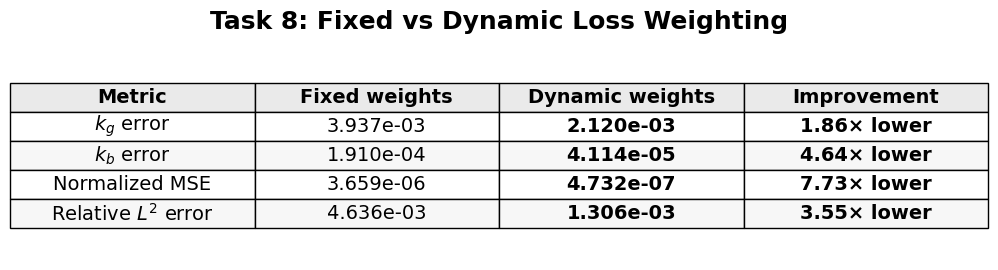

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# Data
table_data = {
    "Metric": [
        r"$k_g$ error",
        r"$k_b$ error",
        "Normalized MSE",
        r"Relative $L^2$ error"
    ],
    "Fixed weights": [
        "3.937e-03",
        "1.910e-04",
        "3.659e-06",
        "4.636e-03"
    ],
    "Dynamic weights": [
        "2.120e-03",
        "4.114e-05",
        "4.732e-07",
        "1.306e-03"
    ],
    "Improvement": [
        "1.86× lower",
        "4.64× lower",
        "7.73× lower",
        "3.55× lower"
    ]
}

df = pd.DataFrame(table_data)

# Create figure
fig, ax = plt.subplots(figsize=(10, 2.8))
ax.axis("off")

table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

# Styling
table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1.2, 1.8)

# Header styling
for col in range(len(df.columns)):
    cell = table[(0, col)]
    cell.set_text_props(weight="bold")
    cell.set_facecolor("#EAEAEA")

# Bold dynamic weights and improvement columns
for row in range(1, len(df) + 1):
    table[(row, 2)].set_text_props(weight="bold")
    table[(row, 3)].set_text_props(weight="bold")

# Light row shading
for row in range(1, len(df) + 1):
    if row % 2 == 0:
        for col in range(len(df.columns)):
            table[(row, col)].set_facecolor("#F7F7F7")

plt.title(
    "Task 8: Fixed vs Dynamic Loss Weighting",
    fontsize=18,
    weight="bold",
    pad=16
)

plt.tight_layout()
plt.show()